In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torch.utils.data import random_split
import pandas as pd

import matplotlib.pyplot as plt


In [2]:
class LinearRegression(torch.nn.Module):
    def __init__(self, width, depth, skip = 1):
        super().__init__()

        self.input_l = torch.nn.Linear(2, width)
        self.hidden_l = torch.nn.ModuleList([torch.nn.Linear(width, width) for i in range(depth)])
        self.output_l = torch.nn.Linear(width, 1) # two hidden layer, Depth = 2
        self.act = torch.nn.ReLU()

        self.skip = skip
    
    def forward(self, x):
        a = self.act(self.input_l(x))

        for idx, linear in enumerate(self.hidden_l):
            z = self.act(linear(a))
            if idx % self.skip == 0:
                a = a + z
            else:
                a = z
                
        return self.output_l(a)

linear_regression_model = LinearRegression(width = 10, depth = 10)
linear_regression_model

LinearRegression(
  (input_l): Linear(in_features=2, out_features=10, bias=True)
  (hidden_l): ModuleList(
    (0-9): 10 x Linear(in_features=10, out_features=10, bias=True)
  )
  (output_l): Linear(in_features=10, out_features=1, bias=True)
  (act): ReLU()
)

In [3]:
def noise(shape, low=-1.0, high=1.0):
    return (high - low) * torch.rand(shape) + low

def fn(x):
    return (
        torch.sin(5*x[:, 0].unsqueeze(1))
        + torch.cos(5*x[:, 1].unsqueeze(1))
        + noise((x.shape[0], 1), low=0, high=1)
    ) # x[:, 0] are xs; x[:, 0] are the ys

class x_y_ds(Dataset):
    def __init__(self, fn, N):
        # self.xs = torch.linspace(min, max, N).unsqueeze(1)
        # self.ys = fn(self.xs)

        self.xs = torch.rand(N, 2) * 5
        self.ys = fn(self.xs)

    def __len__(self):
        return len(self.ys)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys[idx]
    
data = x_y_ds(fn, N = 100)
training_dataset, test_dataset = random_split(
    data, [80, 20]
)
    
train_dataloader = DataLoader(dataset = training_dataset, batch_size=10, shuffle=True)
test_dataloader = DataLoader(dataset = test_dataset, batch_size=10, shuffle=False)

In [4]:
widths = [10, 30]
depths = [10, 30]

logs = {}
nn_enum = 0
for w in widths:
    for d in depths:
        logs[f"NN{nn_enum}"] = {
                    "width": w,
                    "Depth": d,
                    "train_loss": [],
                    "test_loss": [],
                    "training_convergence_epoch": 1000,
                    "testing_convergence_epoch": 1000,
                    }
        nn_enum += 1

In [5]:
loss_fn = torch.nn.MSELoss()

skip = 5

epsilon_2 = 0.4
epsilon = 0.15
epochs = 1000
lr = 0.01

for NN, log in logs.items():
    old_train_loss = None
    old_test_loss = None
    is_training_converged = False
    is_testing_converged = False

    model = LinearRegression(width=log["width"], depth=log["Depth"], skip=skip)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        epoch_loss_train= 0
        for x_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            epoch_loss_train+= loss.item()
            loss.backward()
            optimizer.step()
        
        epoch_loss_train /= len(train_dataloader)

        # checking convergence
        if old_train_loss is None:
            old_train_loss = epoch_loss_train
        else:
            if (abs(epoch_loss_train - old_train_loss) < epsilon_2) and (epoch_loss_train < epsilon) and (is_training_converged == False):
                 is_training_converged = True 
                 log["training_convergence_epoch"] = epoch
            old_train_loss = epoch_loss_train

        epoch_loss_test = 0
        with torch.no_grad():
            for x_batch_test, y_batch_test in test_dataloader:
                y_pred_test = model(x_batch_test)
                loss_test = loss_fn(y_pred_test, y_batch_test)
                epoch_loss_test += loss_test.item()
            epoch_loss_test /= len(test_dataloader)

        log["train_loss"].append(epoch_loss_train)
        log["test_loss"].append(epoch_loss_test)

        # checking convergence and early stoppage
        if old_test_loss is None:
             old_test_loss = epoch_loss_test
        else:
            if ((epoch_loss_test - old_test_loss) < epsilon_2) and (epoch_loss_test < epsilon) and (is_testing_converged == False) and (is_training_converged == True):
                is_testing_converged = True 
                log["testing_convergence_epoch"] = epoch
                print("converged\n")
                break

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | train loss = {epoch_loss_train:.4f} | test loss = {epoch_loss_test:.4f}")



Epoch 0 | train loss = 1.0937 | test loss = 0.9606
Epoch 100 | train loss = 1.0537 | test loss = 0.9982
Epoch 200 | train loss = 1.0510 | test loss = 1.0003
Epoch 300 | train loss = 1.0810 | test loss = 0.9541
Epoch 400 | train loss = 1.0812 | test loss = 0.9554
Epoch 500 | train loss = 1.0806 | test loss = 0.9541
Epoch 600 | train loss = 1.0812 | test loss = 0.9547
Epoch 700 | train loss = 1.0822 | test loss = 0.9539
Epoch 800 | train loss = 1.0811 | test loss = 0.9543
Epoch 900 | train loss = 1.0807 | test loss = 0.9548
Epoch 0 | train loss = 1.3816 | test loss = 1.0522
Epoch 100 | train loss = 1.0833 | test loss = 0.9583
Epoch 200 | train loss = 1.0810 | test loss = 0.9563
Epoch 300 | train loss = 1.0868 | test loss = 0.9576
Epoch 400 | train loss = 1.0813 | test loss = 0.9561
Epoch 500 | train loss = 1.0811 | test loss = 0.9548
Epoch 600 | train loss = 1.0823 | test loss = 0.9533
Epoch 700 | train loss = 1.0822 | test loss = 0.9540
Epoch 800 | train loss = 1.0797 | test loss = 0.95

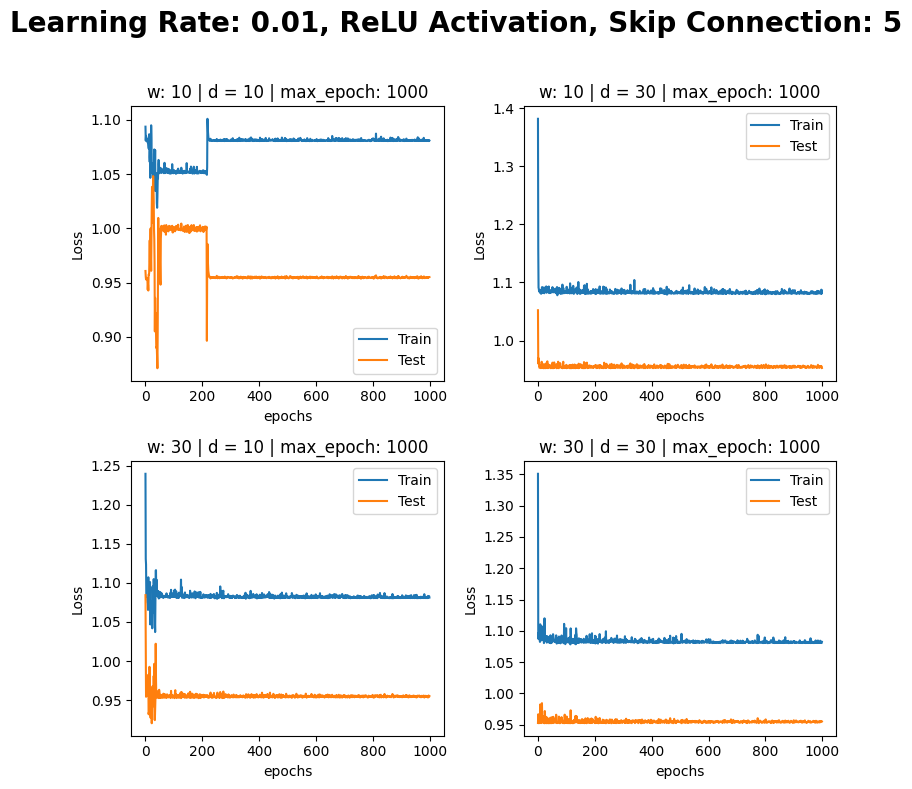

In [6]:
fig, axes = plt.subplots(len(widths), len(depths), figsize=(8, 8))

nn_enum = 0
for i, w in enumerate(widths):
    for j, d in enumerate(depths):
        log = logs[f"NN{nn_enum}"]
        axes[i][j].plot(log["train_loss"], label="Train")
        axes[i][j].plot(log["test_loss"], label="Test")
        axes[i][j].legend()
        nn_enum += 1

        axes[i][j].set(xlabel='epochs', ylabel='Loss')
        axes[i][j].set_title(f"w: {log['width']} | d = {log['Depth']} | max_epoch: {len(log['train_loss'])}")

fig.suptitle(
    f"Learning Rate: {lr}, ReLU Activation, Skip Connection: {skip}",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])



In [ ]:
batch_sizes = [10, 30, 50, 70, 90, 100]
logs = {}
for bs in batch_sizes:
    logs[bs] = {"train_loss": [], "test_loss": []}
    train_dataloader = DataLoader(dataset = training_dataset, batch_size=bs, shuffle=True)
    test_dataloader = DataLoader(dataset = test_dataset, batch_size=bs, shuffle=False)

    logs[bs]["batch_size"] = bs
    model = LinearRegression(width=30, depth=10)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        epoch_loss_train= 0
        for x_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            epoch_loss_train+= loss.item()
            loss.backward()
            optimizer.step()
        
        epoch_loss_train /= len(train_dataloader)
        
        epoch_loss_test = 0
        with torch.no_grad():
            for x_batch_test, y_batch_test in test_dataloader:
                y_pred_test = model(x_batch_test)
                loss_test = loss_fn(y_pred_test, y_batch_test)
                epoch_loss_test += loss_test.item()
            epoch_loss_test /= len(test_dataloader)

        logs[bs]["train_loss"].append(epoch_loss_train)
        logs[bs]["test_loss"].append(epoch_loss_test)

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | train loss = {epoch_loss_train:.4f} | test loss = {epoch_loss_test:.4f}")

        if (epoch_loss_train < epsilon) and (epoch_loss_test < epsilon): 
            print("converged")
            break

Epoch 0 | train loss = 25.0653 | test loss = 27.4127
Epoch 100 | train loss = 0.1744 | test loss = 0.6727
Epoch 200 | train loss = 0.0795 | test loss = 0.5180
Epoch 300 | train loss = 0.1110 | test loss = 0.4619
Epoch 400 | train loss = 0.0781 | test loss = 0.4362
Epoch 500 | train loss = 0.0479 | test loss = 0.4794
Epoch 600 | train loss = 0.0733 | test loss = 0.4698
Epoch 700 | train loss = 0.0332 | test loss = 0.3998
Epoch 800 | train loss = 0.0877 | test loss = 0.4466
Epoch 900 | train loss = 0.1449 | test loss = 0.5022
Epoch 0 | train loss = 20.2472 | test loss = 24.0974
Epoch 100 | train loss = 0.3257 | test loss = 0.4688
Epoch 200 | train loss = 0.0928 | test loss = 0.5214
Epoch 300 | train loss = 0.0680 | test loss = 0.5271
Epoch 400 | train loss = 0.0572 | test loss = 0.4935
Epoch 500 | train loss = 0.0537 | test loss = 0.4821
Epoch 600 | train loss = 0.0381 | test loss = 0.3885
Epoch 700 | train loss = 0.0812 | test loss = 0.3159
Epoch 800 | train loss = 0.0323 | test loss = 

In [ ]:
for bs in logs.keys():
    logs[bs]["tr_len"] = len(logs[bs]['train_loss'])
    logs[bs]["te_len"] = len(logs[bs]['test_loss'])
    del logs[bs]["train_loss"]
    del logs[bs]["test_loss"]

In [ ]:
pd.DataFrame(logs)

,10,30,50,70,90,100
batch_size,10,30,50,70,90,100
tr_len,1000,1000,1000,1000,1000,1000
te_len,1000,1000,1000,1000,1000,1000


In [ ]:
logs

{10: {'batch_size': 10, 'tr_len': 1000, 'te_len': 1000},
 30: {'batch_size': 30, 'tr_len': 1000, 'te_len': 1000},
 50: {'batch_size': 50, 'tr_len': 1000, 'te_len': 1000},
 70: {'batch_size': 70, 'tr_len': 1000, 'te_len': 1000},
 90: {'batch_size': 90, 'tr_len': 1000, 'te_len': 1000},
 100: {'batch_size': 100, 'tr_len': 1000, 'te_len': 1000}}